In [32]:
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
import networkx as nx
import pickle

In [33]:
### FUNCTIONS
import numpy as np

def basin_centered_laea(geom):
    from pyproj import CRS
    lon0, lat0 = geom.centroid.coords[0]
    return CRS.from_proj4(
        f"+proj=laea +lat_0={lat0} +lon_0={lon0} "
        "+datum=WGS84 +units=m +no_defs"
    )

def getRotationAngle(outlet_coords,divide_coords):
    vec = np.array(divide_coords) - np.array(outlet_coords)
    return np.arctan2(vec[1],vec[0])*180/np.pi

def getBasin_ratio(
    shape,
    network,
    id,
    area_threshold=5e6,
    n_pca_samples=2000
):
    import numpy as np
    import geopandas as gpd
    from shapely.geometry import Point, MultiPolygon
    from shapely.ops import unary_union
    from shapely.affinity import rotate

    """
    Compute basin aspect ratio using:
      (1) Hydrologically aligned rotation-based method
      (2) Geometry-only PCA-based method

    Parameters
    ----------
    shape : shapely Polygon or MultiPolygon (EPSG:4326)
        Basin geometry
    network : networkx graph
        River network
    id : hashable
        Outlet node id
    area_threshold : float
        Area threshold (m²) to switch CRS logic
    n_pca_samples : int
        Number of boundary samples for PCA

    Returns
    -------
    dict with keys:
        ratio_rot       : width / height (rotation-based)
        ratio_pca       : sqrt(lambda1 / lambda2)
        width_km        : basin width (km)
        height_km       : basin height (km)
        outlet_loc      : normalized outlet x-position
    """

    # ------------------------------------------------------------------
    # 1. Basin GeoDataFrame (assume WGS84 input)
    # ------------------------------------------------------------------
    basin_gdf = gpd.GeoDataFrame(
        geometry=[shape],
        crs="EPSG:4326"
    )

    # ------------------------------------------------------------------
    # 2. CRS selection
    # ------------------------------------------------------------------
    area = basin_gdf.to_crs("EPSG:6933").area.iloc[0]

    if area < area_threshold:
        crs = basin_gdf.estimate_utm_crs()
    else:
        crs = basin_centered_laea(shape)

    basin_proj = basin_gdf.to_crs(crs)

    # ------------------------------------------------------------------
    # 3. Outlet coordinates (explicit & safe)
    # ------------------------------------------------------------------
    outlet_x = network.nodes[id]["x"]
    outlet_y = network.nodes[id]["y"]

    outlet_point = gpd.GeoSeries(
        [Point(outlet_x, outlet_y)],
        crs="EPSG:4326"
    ).to_crs(crs).iloc[0]

    outlet_coords = np.array([outlet_point.x, outlet_point.y])

    # ------------------------------------------------------------------
    # 4. Basin geometry (handle MultiPolygon)
    # ------------------------------------------------------------------
    basin_geom = unary_union(basin_proj.geometry)

    if isinstance(basin_geom, MultiPolygon):
        basin_geom = max(basin_geom.geoms, key=lambda g: g.area)

    # ------------------------------------------------------------------
    # 5. Farthest divide point (hydrological axis)
    # ------------------------------------------------------------------
    divide_coords = np.array(
        max(
            basin_geom.exterior.coords,
            key=lambda c: Point(c).distance(outlet_point)
        )
    )

    # ------------------------------------------------------------------
    # 6. Rotation-based aspect ratio
    # ------------------------------------------------------------------
    basin_angle = getRotationAngle(outlet_coords, divide_coords)
    rotation_angle = -basin_angle + 90

    basin_rot = rotate(
        basin_geom,
        rotation_angle,
        origin=outlet_point,
        use_radians=False
    )

    minx, miny, maxx, maxy = basin_rot.bounds

    width = maxx - minx
    height = np.linalg.norm(divide_coords - outlet_coords)

    ratio_rot = width / height
    outlet_loc = (outlet_coords[0] - minx) / width

    # ------------------------------------------------------------------
    # 7. PCA-based aspect ratio (geometry-only)
    # ------------------------------------------------------------------
    # Sample boundary uniformly
    boundary = np.array(basin_geom.exterior.coords)

    if len(boundary) > n_pca_samples:
        idx = np.linspace(0, len(boundary) - 1, n_pca_samples).astype(int)
        boundary = boundary[idx]

    # Center coordinates
    X = boundary - boundary.mean(axis=0)

    # Covariance & eigenvalues
    cov = np.cov(X.T)
    eigvals = np.linalg.eigvalsh(cov)

    # Ensure ordering: lambda1 >= lambda2
    lambda1, lambda2 = eigvals[::-1]

    ratio_pca = np.sqrt(lambda1 / lambda2)

    # ------------------------------------------------------------------
    # 8. Return results
    # ------------------------------------------------------------------
    return {
        "ratio": ratio_rot-1,
        "ratio_pca": ratio_pca,
        "width_km": width / 1000,
        "height_km": height / 1000,
        "outlet_loc": outlet_loc,
        "basin_rot": basin_rot,
        "basin_rot_anchor": outlet_point,
        "basin_rot_angle": rotation_angle
    }

In [34]:
### LOAD DATA

basins_all = pickle.load(open('./HS_basins_06.pkl', 'rb'))

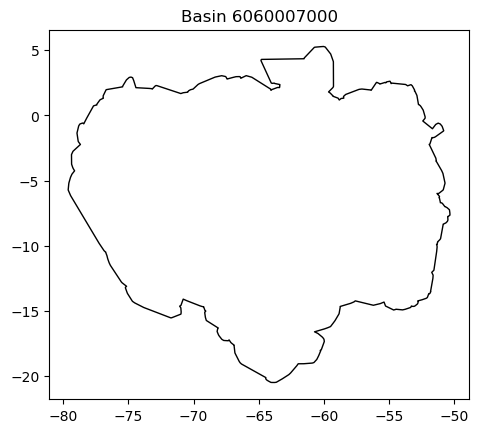

{'ratio': np.float64(-0.13474999790890907), 'ratio_pca': np.float64(1.1630119634611713), 'width_km': 2743.488053835608, 'height_km': np.float64(3170.7460817166016), 'outlet_loc': np.float64(0.6802424089737599), 'basin_rot': <POLYGON ((235166.821 2776763.245, 273517.828 2776513.383, 276164.291 277619...>, 'basin_rot_anchor': <POINT (1469088.247 594566.734)>, 'basin_rot_angle': np.float64(260.7139805188393)}


In [36]:
select_basin = 0
poly = basins_all[select_basin]['shape']

# If it's a shapely Polygon/MultiPolygon, use GeoSeries to plot it
if hasattr(poly, "geom_type"):
	gpd.GeoSeries([poly]).plot(edgecolor="black", facecolor="none")
else:
	# fallback: assume it's already a GeoDataFrame/GeoSeries
	poly.plot(edgecolor="black", facecolor="none")

plt.gca().set_aspect("equal")
plt.title(f"Basin {basins_all[select_basin]['id']}")
plt.show()
#############################

basin_info = getBasin_ratio(
	shape=basins_all[select_basin]['shape'],
	network=basins_all[select_basin]['network'],
	id=basins_all[select_basin]['id']
)
print(basin_info)